In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split


In [2]:
# Load training and test CSV files
train_data = pd.read_csv("fashion-mnist_train.csv")
test_data = pd.read_csv("fashion-mnist_test.csv")

# Separate features and labels
xtrain = train_data.drop("label", axis=1).values
ytrain = train_data["label"].values

xtest = test_data.drop("label", axis=1).values
ytest = test_data["label"].values

#reshaping the input tensor because the mnist input tensor consists of a (28,28,1) grayscale image, but Conv2D requires a 4D tensor.
xtrain = xtrain.reshape(-1,28,28,1).astype('float32') / 255.0
xtest = xtest.reshape(-1,28,28,1).astype('float32') / 255.0

In [3]:
xtrain, xtest, ytrain, ytest = train_test_split(xtrain, ytrain, test_size=0.2, random_state=42)


In [4]:
# Build CNN model
model = Sequential()
model.add(Conv2D(64, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))  # 10 classes

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 64)        640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 64)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 10816)             0         
                                                                 
 dense (Dense)               (None, 128)               1384576   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386506 (5.29 MB)
Trainable params: 1386506 (5.29 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

In [5]:
model.fit(xtrain, ytrain, epochs=5, validation_split=0.2)


Epoch 1/5
1200/1200 [==============================] - 35s 29ms/step - loss: 0.4173 - accuracy: 0.8523 - val_loss: 0.3262 - val_accuracy: 0.8838
Epoch 2/5
1200/1200 [==============================] - 35s 29ms/step - loss: 0.2801 - accuracy: 0.8988 - val_loss: 0.2791 - val_accuracy: 0.9033
Epoch 3/5
1200/1200 [==============================] - 34s 28ms/step - loss: 0.2277 - accuracy: 0.9157 - val_loss: 0.2719 - val_accuracy: 0.9042
Epoch 4/5
1200/1200 [==============================] - 34s 28ms/step - loss: 0.1889 - accuracy: 0.9313 - val_loss: 0.2699 - val_accuracy: 0.9094
Epoch 5/5
1200/1200 [==============================] - 34s 28ms/step - loss: 0.1592 - accuracy: 0.9417 - val_loss: 0.2766 - val_accuracy: 0.9054


In [6]:
# Evaluate on test data
loss, acc = model.evaluate(xtest, ytest)
print("Test Accuracy:", acc)



375/375 [==============================] - 2s 5ms/step - loss: 0.2685 - accuracy: 0.9062
Test Accuracy: 0.906166672706604


1/1 [==============================] - 0s 101ms/step
Predicted label: 7


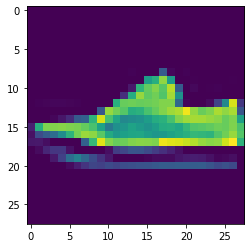

In [7]:
# Predict one sample and show
pred = model.predict(xtest[:1])
print("Predicted label:", np.argmax(pred))
plt.imshow(xtest[0])
plt.show()

1/1 [==============================] - 0s 15ms/step


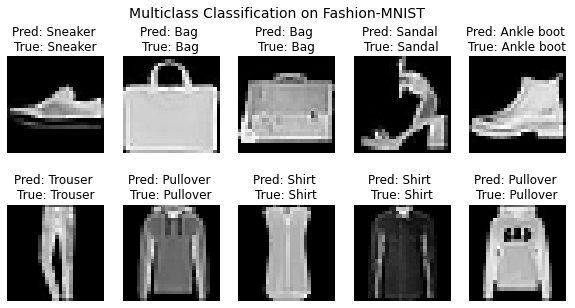

In [10]:
# Class labels for Fashion-MNIST
labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Predict on first 10 test images
predictions = model.predict(xtest[:10])

# Plot images with predicted and actual labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(xtest[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {labels[np.argmax(predictions[i])]} \nTrue: {labels[ytest[i]]}")
    plt.axis('off')

plt.suptitle("Multiclass Classification on Fashion-MNIST", fontsize=14)
#plt.tight_layout()
plt.show()
